Project Title:
Image Classification System using Transfer Learning

Objective:
In this project, we will build a deep learning image classification system.
We will use a pretrained model such as MobileNetV2 or ResNet50.

Dataset:
We will use the Flower Classification dataset because it is simple, clear,
and suitable for transfer learning.

Main Tasks:
1. Load image dataset
2. Preprocess images
3. Apply data augmentation
4. Use pretrained model
5. Train custom classification layers
6. Evaluate model performance
7. Plot graphs
8. Create confusion matrix
9. Fine-tune the model
10. Save and test the model

In [1]:
# ============================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# ============================================================

# Importing core libraries
import os
import numpy as np
import pandas as pd

# Importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Importing OpenCV for webcam functionality
import cv2

# Importing TensorFlow and Keras libraries
import tensorflow as tf
from tensorflow.keras import layers, models

# Importing pretrained transfer learning models
from tensorflow.keras.applications import MobileNetV2, ResNet50

# Importing preprocessing functions for pretrained models
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# Importing image processing utilities
from tensorflow.keras.preprocessing import image

# Importing evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

#visulaization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#removing warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# CELL 2: CHECK DATASET STRUCTURE
# ============================================================

dataset_path = "flowers dataset"

train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")

train_csv_path = os.path.join(dataset_path, "train.csv")
val_csv_path = os.path.join(dataset_path, "val.csv")

print("Train folder exists:", os.path.exists(train_path))
print("Validation folder exists:", os.path.exists(val_path))
print("Train CSV exists:", os.path.exists(train_csv_path))
print("Validation CSV exists:", os.path.exists(val_csv_path))

train_classes = sorted([
    folder for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

val_classes = sorted([
    folder for folder in os.listdir(val_path)
    if os.path.isdir(os.path.join(val_path, folder))
])

print("\nTotal training classes:", len(train_classes))
print("Total validation classes:", len(val_classes))

print("\nTraining Classes:")
print(train_classes)

Train folder exists: True
Validation folder exists: True
Train CSV exists: True
Validation CSV exists: True

Total training classes: 14
Total validation classes: 14

Training Classes:
['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [3]:
# ============================================================
# CELL 3: READ CSV FILES AND CHECK LABEL INFORMATION
# ============================================================

train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)

print("Training CSV Preview:")
display(train_df.head())

print("Validation CSV Preview:")
display(val_df.head())

print("Training CSV Shape:", train_df.shape)
print("Validation CSV Shape:", val_df.shape)

Training CSV Preview:


,images,category
0,train/carnation/6838762136_f8254d6a1a_c.jpg,0
1,train/carnation/3540544866_823aee81af_c.jpg,0
2,train/carnation/50034862576_b0f55b7b3b_c.jpg,0
3,train/carnation/26770795691_f662e47143_c.jpg,0
4,train/carnation/18224456534_2f75191d85_c.jpg,0


Validation CSV Preview:


,images,category
0,val/carnation/51286244394_853e894860_c.jpg,0
1,val/carnation/16915050250_4bae79aa6d_c.jpg,0
2,val/carnation/364467920_420ddab32e_c.jpg,0
3,val/carnation/213392504_2eaf4f8816_c.jpg,0
4,val/carnation/3315280754_132d0f2161_c.jpg,0


Training CSV Shape: (13642, 2)
Validation CSV Shape: (98, 2)


,Class,Image Count
0,astilbe,726
1,bellflower,872
2,black_eyed_susan,986
3,calendula,1011
4,california_poppy,1021
5,carnation,924
6,common_daisy,978
7,coreopsis,1035
8,dandelion,1038
9,iris,1041


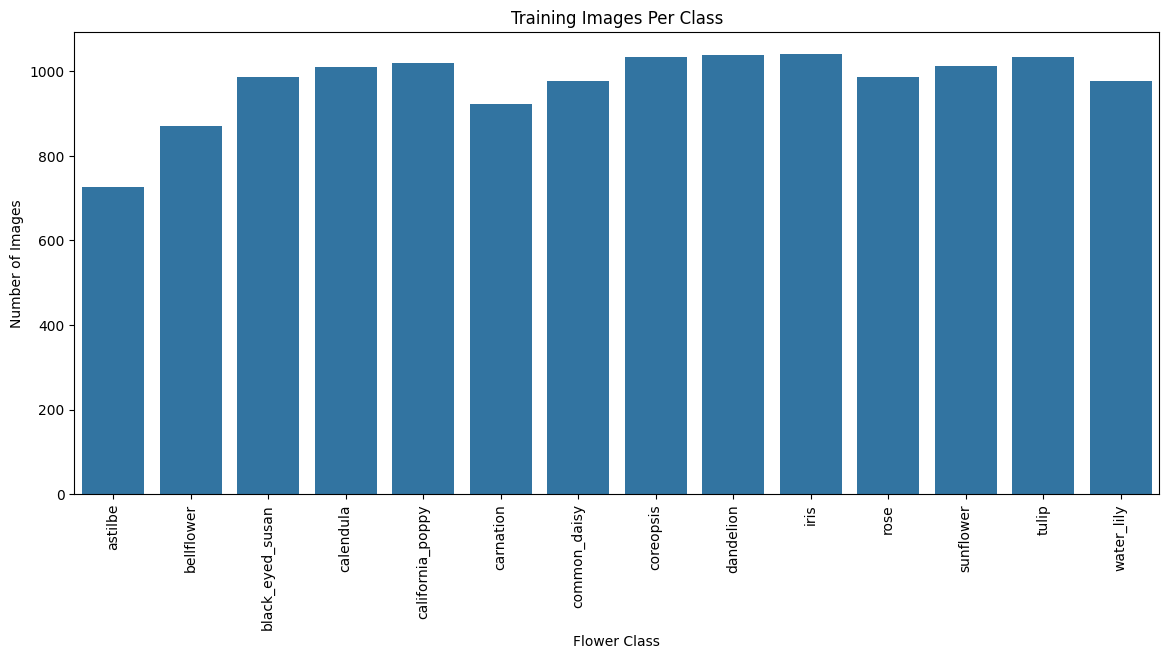

In [4]:
# ============================================================
# CELL 4: CHECK IMAGE COUNT PER CLASS
# ============================================================

class_counts = {}

# Counting images in each class folder for training dataset
for class_name in train_classes:
    class_folder = os.path.join(train_path, class_name)
    image_count = len([
        file for file in os.listdir(class_folder)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    class_counts[class_name] = image_count

# Displaying image count per class in a DataFrame
class_count_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image Count"]
)

display(class_count_df)

# Visualize the image count per class using a bar plot
plt.figure(figsize=(14, 6))
sns.barplot(data=class_count_df, x="Class", y="Image Count")
plt.title("Training Images Per Class")
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.show()

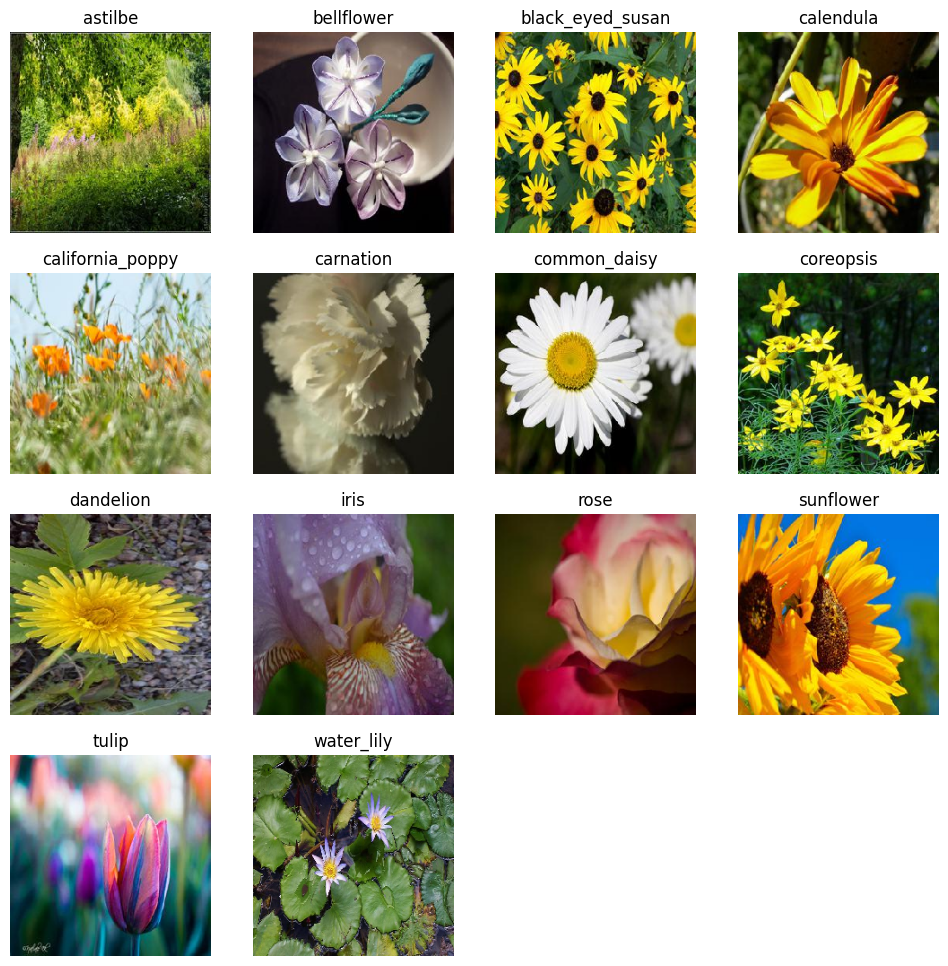

In [5]:
# ============================================================
# CELL 5: VISUALIZE SAMPLE IMAGES
# ============================================================

# visualize one sample image from each of the 14 classes in the training dataset
plt.figure(figsize=(12, 12))

for i, class_name in enumerate(train_classes[:14]):
    class_folder = os.path.join(train_path, class_name)
    image_name = os.listdir(class_folder)[0]
    image_path = os.path.join(class_folder, image_name)

    img = image.load_img(image_path, target_size=(224, 224))

    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [6]:
# ============================================================
# CELL 6: CREATE DATA GENERATORS
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
MODEL_NAME = "MobileNetV2"

if MODEL_NAME == "MobileNetV2":
    preprocess_function = mobilenet_preprocess
else:
    preprocess_function = resnet_preprocess

# Creating data generators with augmentation for training and only preprocessing for validation
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_function,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_function
)

In [7]:
# ============================================================
# CELL 7: LOAD TRAINING AND VALIDATION DATA
# ============================================================

# Loading training and validation data from directories
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

# Loading validation data without shuffling to maintain order for evaluation
val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Displaying class indices and total number of classes
class_names = list(train_data.class_indices.keys())

print("Class Mapping:")
print(train_data.class_indices)

print("\nTotal Classes:", train_data.num_classes)

Found 13642 images belonging to 14 classes.
Found 98 images belonging to 14 classes.
Class Mapping:
{'astilbe': 0, 'bellflower': 1, 'black_eyed_susan': 2, 'calendula': 3, 'california_poppy': 4, 'carnation': 5, 'common_daisy': 6, 'coreopsis': 7, 'dandelion': 8, 'iris': 9, 'rose': 10, 'sunflower': 11, 'tulip': 12, 'water_lily': 13}

Total Classes: 14


In [8]:
# ============================================================
# CELL 8: BUILD TRANSFER LEARNING MODEL
# ============================================================

# Loading the pretrained model based on the selected MODEL_NAME
if MODEL_NAME == "MobileNetV2":
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
else:
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

base_model.trainable = False

# Adding custom classification head on top of the base model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,758 (9.25 MB)

 Trainable params: 165,774 (647.55 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# ============================================================
# CELL 9: COMPILE MODEL
# ============================================================

# Compiling the model with Adam optimizer and categorical crossentropy loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
# ============================================================
# CELL 10: TRAIN MODEL
# ============================================================

# Training the model for 10 epochs with training and validation data
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 318s 730ms/step - accuracy: 0.7144 - loss: 0.8986 - val_accuracy: 0.8265 - val_loss: 0.4817
Epoch 2/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 300s 702ms/step - accuracy: 0.8232 - loss: 0.5514 - val_accuracy: 0.8469 - val_loss: 0.4631
Epoch 3/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 306s 716ms/step - accuracy: 0.8435 - loss: 0.4819 - val_accuracy: 0.8878 - val_loss: 0.3644
Epoch 4/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 295s 691ms/step - accuracy: 0.8526 - loss: 0.4507 - val_accuracy: 0.8367 - val_loss: 0.3440
Epoch 5/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 296s 694ms/step - accuracy: 0.8600 - loss: 0.4188 - val_accuracy: 0.9082 - val_loss: 0.3267
Epoch 6/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 310s 725ms/step - accuracy: 0.8653 - loss: 0.4025 - val_accuracy: 0.8878 - val_loss: 0.3696
Epoch 7/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 303s 709ms/step - accuracy: 0.8700 - loss: 0.3977 - val_accuracy: 0.8980 - val_loss: 0.2910
Epoch 8/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 295s 689ms/step - accuracy: 0.8714 -

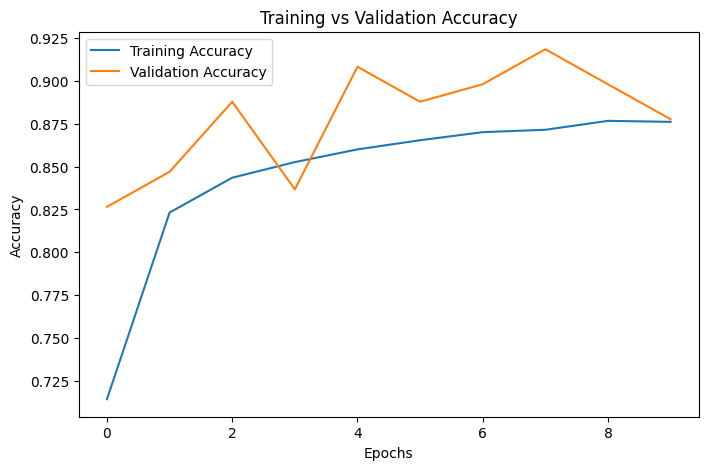

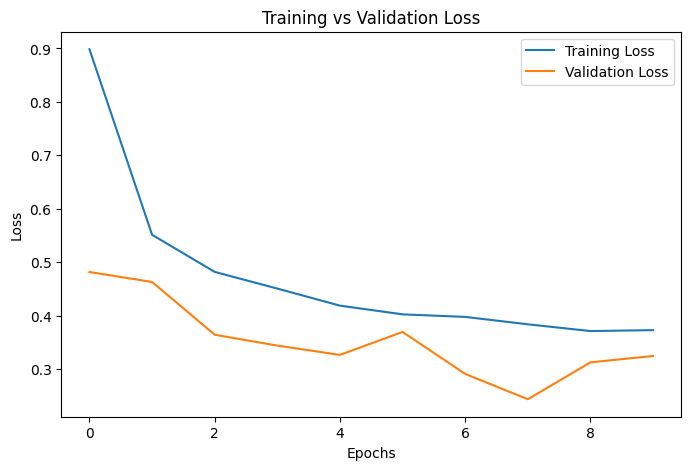

In [11]:
# ============================================================
# CELL 11: PLOT ACCURACY AND LOSS
# ============================================================

# Plotting training and validation accuracy over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plotting training and validation loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [12]:
# ============================================================
# CELL 12: EVALUATE MODEL
# ============================================================

# Evaluating model on validation dataset
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.8776 - loss: 0.3246
Validation Loss: 0.32458245754241943
Validation Accuracy: 0.8775510191917419


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 862ms/step


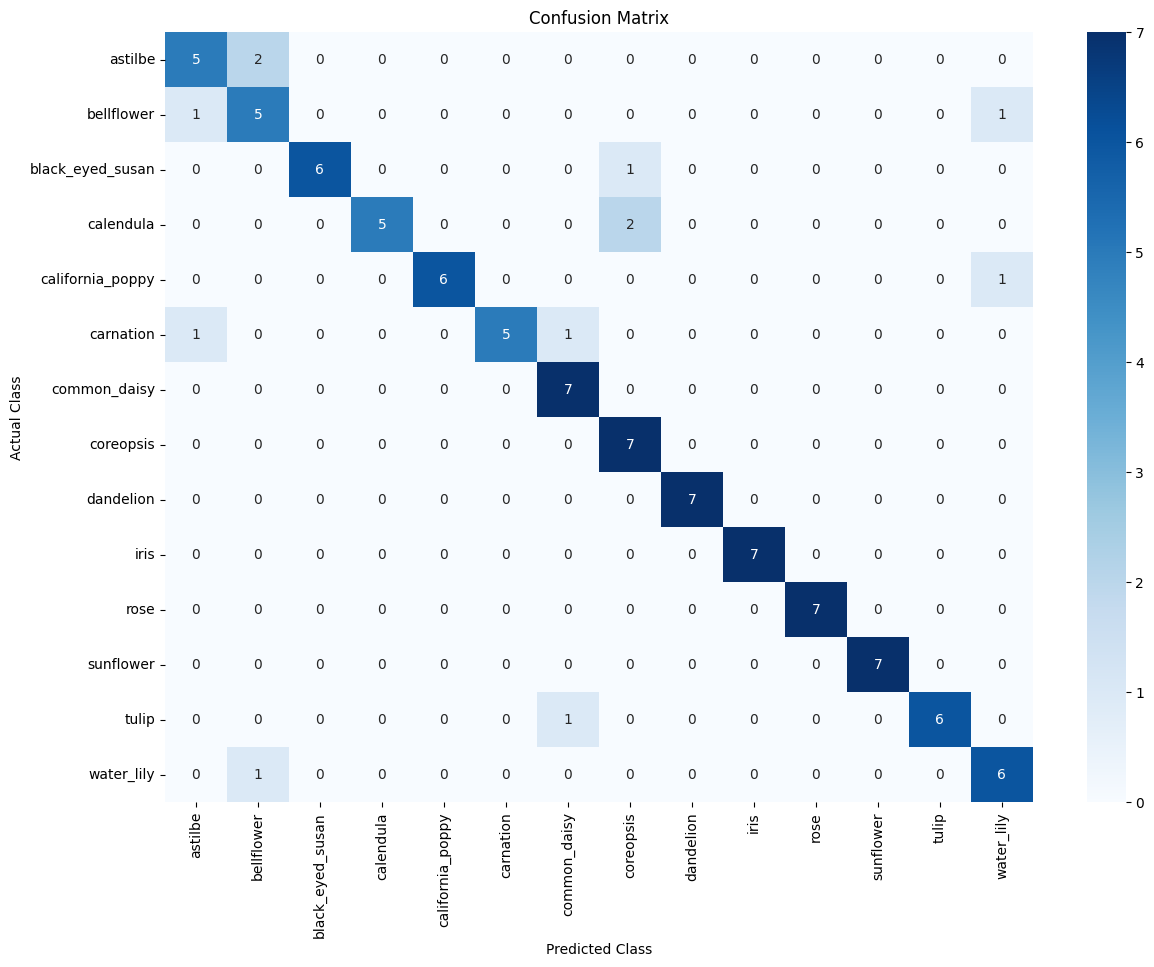

Classification Report:
                  precision    recall  f1-score   support

         astilbe       0.71      0.71      0.71         7
      bellflower       0.62      0.71      0.67         7
black_eyed_susan       1.00      0.86      0.92         7
       calendula       1.00      0.71      0.83         7
california_poppy       1.00      0.86      0.92         7
       carnation       1.00      0.71      0.83         7
    common_daisy       0.78      1.00      0.88         7
       coreopsis       0.70      1.00      0.82         7
       dandelion       1.00      1.00      1.00         7
            iris       1.00      1.00      1.00         7
            rose       1.00      1.00      1.00         7
       sunflower       1.00      1.00      1.00         7
           tulip       1.00      0.86      0.92         7
      water_lily       0.75      0.86      0.80         7

        accuracy                           0.88        98
       macro avg       0.90      0.88      0.88

In [13]:
# ============================================================
# CELL 13: CONFUSION MATRIX AND CLASSIFICATION REPORT
# ============================================================

val_data.reset()

# Generating predictions for the validation dataset
predictions = model.predict(val_data)
y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

# Visualizing the confusion matrix using a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [14]:
# ============================================================
# CELL 14: FINE-TUNE MODEL
# ============================================================

# Unfreezing the last 30 layers of the base model for fine-tuning
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
427/427 ━━━━━━━━━━━━━━━━━━━━ 401s 917ms/step - accuracy: 0.7684 - loss: 0.7587 - val_accuracy: 0.8673 - val_loss: 0.3619
Epoch 2/5
427/427 ━━━━━━━━━━━━━━━━━━━━ 350s 819ms/step - accuracy: 0.8540 - loss: 0.4471 - val_accuracy: 0.8980 - val_loss: 0.2671
Epoch 3/5
427/427 ━━━━━━━━━━━━━━━━━━━━ 318s 743ms/step - accuracy: 0.8709 - loss: 0.3932 - val_accuracy: 0.9082 - val_loss: 0.2637
Epoch 4/5
427/427 ━━━━━━━━━━━━━━━━━━━━ 313s 734ms/step - accuracy: 0.8855 - loss: 0.3480 - val_accuracy: 0.9184 - val_loss: 0.2403
Epoch 5/5
427/427 ━━━━━━━━━━━━━━━━━━━━ 315s 737ms/step - accuracy: 0.8939 - loss: 0.3381 - val_accuracy: 0.9286 - val_loss: 0.2334


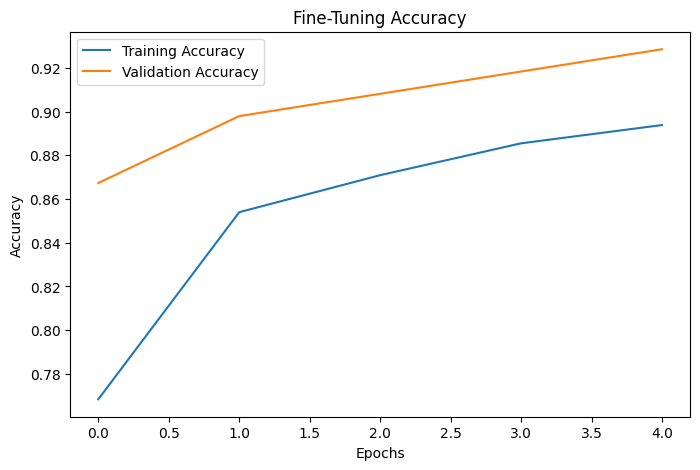

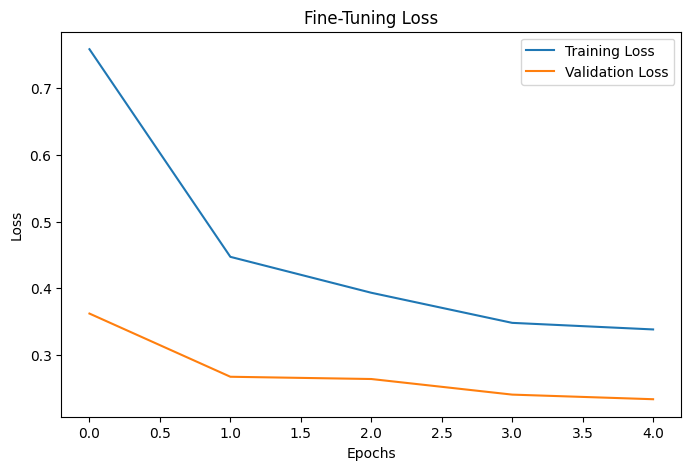

In [15]:
# ============================================================
# CELL 15: PLOT FINE-TUNING RESULTS
# ============================================================

# Plotting fine-tuning accuracy over epochs
plt.figure(figsize=(8, 5))
plt.plot(fine_tune_history.history["accuracy"], label="Training Accuracy")
plt.plot(fine_tune_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plotting fine-tuning loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(fine_tune_history.history["loss"], label="Training Loss")
plt.plot(fine_tune_history.history["val_loss"], label="Validation Loss")
plt.title("Fine-Tuning Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [16]:
# ============================================================
# CELL 16: SAVE MODEL
# ============================================================
import json

# Creating a directory to save the trained model if it doesn't exist

os.makedirs("models", exist_ok=True)

# Saving the trained model in HDF5 format
model.save("models/flower_classification_model.h5")

with open("models/class_names.json", "w") as file:
    json.dump(class_names, file)

print("Model saved successfully.")

Model saved successfully.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


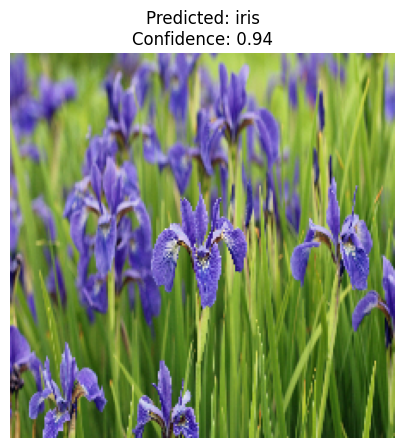

Predicted Class: iris
Confidence: 0.9425597


In [21]:
# ============================================================
# CELL 17: TEST SINGLE IMAGE PREDICTION
# ============================================================

# Function to predict the class of a single image and display the result
def predict_single_image(image_path):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = preprocess_function(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_index = np.argmax(prediction)
    confidence = np.max(prediction)
    predicted_class = class_names[predicted_index]
    
    # Displaying the image along with predicted class and confidence
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}")
    plt.axis("off")
    plt.show()

    print("Predicted Class:", predicted_class)
    print("Confidence:", confidence)


predict_single_image("test.jpg")

In [ ]:
# ============================================================
# CELL 18: REAL-TIME WEBCAM PREDICTION
# ============================================================

def webcam_prediction():
    cap = cv2.VideoCapture(0)

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        resized_frame = cv2.resize(frame, (224, 224))
        img_array = preprocess_function(resized_frame)
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array, verbose=0)

        predicted_index = np.argmax(prediction)
        confidence = np.max(prediction)

        if confidence < 0.60:
            label = "Unknown Flower"
        else:
            label = f"{class_names[predicted_index]}: {confidence:.2f}"

        cv2.putText(
            frame,
            label,
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

        cv2.imshow("Flower Classification", frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()


#webcam_prediction() #uncomment this line to enable webcam prediction functionality. Press 'q' to exit the webcam window.

The real-time webcam feature is included as a bonus feature. However, image upload prediction is more reliable because webcam frames can be affected by lighting, camera quality, background noise, and flower position.